In [102]:
from pathlib import Path
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS
from typing import TypedDict, List
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

#### LLM

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

#### Load Text Documents

In [ ]:
# def load_txt_documents(folder, category):

#     documents = []

#     files = Path(folder).glob("*.txt")

#     for file in files:
#         loader = TextLoader(
#             str(file),
#             encoding="utf-8"
#         )

#         docs = loader.load()

#         for doc in docs:
#             doc.metadata["domain"] = "ageye"
#             doc.metadata["category"] = category
#             doc.metadata["product"] = file.stem

#         documents.extend(docs)

#     return documents


# equipment_documents = load_txt_documents("ageye_knowledge/equipment","equipment")
# plant_documents = load_txt_documents("ageye_knowledge/plant_analysis","plant_analysis")
# aris_documents = load_txt_documents("ageye_knowledge/aris","aris")
# general_documents = load_txt_documents("ageye_knowledge/general","general")

In [2]:
equipment_documents = []
plant_documents = []
aris_documents = []
general_documents = []

In [3]:
equipment_files = Path("ageye_knowledge/equipment").glob("*.txt")
plant_analysis_files = Path("ageye_knowledge/plant_analysis").glob("*.txt")
aris_files = Path("ageye_knowledge/aris").glob("*.txt")
general_files = Path("ageye_knowledge/general").glob("*.txt")

for file in equipment_files:
    loader = TextLoader(str(file),encoding="utf-8")
    docs = loader.load()
    equipment_documents.extend(docs)

    for file in plant_analysis_files:
        loader = TextLoader(str(file),encoding="utf-8")
        docs = loader.load()
        plant_documents.extend(docs)

        for file in aris_files:
            loader = TextLoader(str(file),encoding="utf-8")
            docs = loader.load()
            aris_documents.extend(docs)

            for file in general_files:
                loader = TextLoader(str(file),encoding="utf-8")
                docs = loader.load()
                general_documents.extend(docs)


print("Equipment documents:", len(equipment_documents))
print("Plant documents:", len(plant_documents))
print("ARIS documents:", len(aris_documents))
print("General documents:", len(general_documents))

Equipment documents: 4
Plant documents: 4
ARIS documents: 3
General documents: 1


In [4]:
equipment_documents

[Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_harvester.txt'}, page_content='Automated Harvester\nConsistent, rapid harvesting that maintains product quality and reduces handling damage. Designed for the crop types and tray formats used in commercial vertical farming, with throughput matched to production plan targets.\n\nConsistent cut quality and product handling\nThroughput matched to production plan\nReduces harvest labor and handling damage\nYield and quality data captured per batch'),
 Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_seeder.txt'}, page_content='Automated Seeder\nPrecision seeding at scale. Handles multiple seed types and tray configurations with consistent placement accuracy, eliminating the variability and labor cost of manual seeding. Integrated with crop scheduling so seeding runs are auto-triggered based on the production plan.\n\nConsistent seed placement across tray formats\nMulti-seed-type capability\nTriggered aut

In [5]:
plant_documents

[Document(metadata={'source': 'ageye_knowledge\\plant_analysis\\basil.txt'}, page_content='AGEYE PLANT ANALYSIS – BASIL\n\nPlant Name: Basil\nScientific Name: Ocimum basilicum\nCategory: Herb\nAnalysis Domain: Plant Health Monitoring\n\nOverview\n\nBasil is an aromatic herb commonly analyzed using plant image analysis techniques. AGEYE plant analysis can process images of basil plants to identify plant regions, leaves, and visible leaf abnormalities.'),
 Document(metadata={'source': 'ageye_knowledge\\plant_analysis\\deficiency_analysis.txt'}, page_content='AGEYE PLANT ANALYSIS – DEFICIENCY ANALYSIS\n\nAnalysis Domain: Plant Visual Health\nPurpose: Computer Vision and RAG Demonstration\n\nOverview\n\nPlant deficiency analysis can use image-based features to identify visible changes in plant leaves.'),
 Document(metadata={'source': 'ageye_knowledge\\plant_analysis\\hemp.txt'}, page_content='AGEYE PLANT ANALYSIS – HEMP\n\nPlant Name: Hemp\nScientific Name: Cannabis sativa\nCategory: Plant

In [6]:
aris_documents

[Document(metadata={'source': 'ageye_knowledge\\aris\\aris_features.txt'}, page_content='AGEYE ARIS – FEATURES AND COMPONENTS\n\nSystem: ARIS\nDomain: AGEYE\n\nCore Features\n\nARIS can contain the following functional capabilities:\n\nImage acquisition\nPlant detection\nLeaf detection\nImage segmentation\nFeature extraction\nPlant analysis\nMachine monitoring\nSensor-data processing\nData validation\nResult generation\nReporting'),
 Document(metadata={'source': 'ageye_knowledge\\aris\\aris_overview.txt'}, page_content='AGEYE ARIS – SYSTEM OVERVIEW\n\nSystem Name: ARIS\nDomain: AGEYE\nCategory: Agricultural Robotics and Intelligent Systems\nPurpose: Intelligent analysis and automation\n\nOverview\n\nARIS is an intelligent system designed to support agricultural operations through automation, sensing, computer vision, data processing, and intelligent decision support.'),
 Document(metadata={'source': 'ageye_knowledge\\aris\\aris_workflow.txt'}, page_content='AGEYE ARIS – WORKFLOW\n\nSys

In [7]:
general_documents

[Document(metadata={'source': 'ageye_knowledge\\general\\ageye_overview.txt'}, page_content='AGEYE – GENERAL SYSTEM OVERVIEW\n\nSystem: AGEYE\nDomain: Agricultural Technology\nPurpose: Plant, equipment, image, and agricultural data analysis\n\nOverview\n\nAGEYE is an intelligent agricultural technology platform that can combine computer vision, machine learning, automation, data processing, and analytics.\n\nThe platform can process plant images, equipment information, sensor data, and operational information.')]

In [8]:
for doc in equipment_documents:
    doc.metadata["domain"] = "ageye"
    doc.metadata["category"] = "equipment"

    for doc in plant_documents:
        doc.metadata["domain"] = "ageye"
        doc.metadata["category"] = "plant_analysis"

        for doc in aris_documents:
            doc.metadata["domain"] = "ageye"
            doc.metadata["category"] = "aris"

            for doc in general_documents:
                doc.metadata["domain"] = "ageye"
                doc.metadata["category"] = "general"

In [9]:
equipment_documents

[Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_harvester.txt', 'domain': 'ageye', 'category': 'equipment'}, page_content='Automated Harvester\nConsistent, rapid harvesting that maintains product quality and reduces handling damage. Designed for the crop types and tray formats used in commercial vertical farming, with throughput matched to production plan targets.\n\nConsistent cut quality and product handling\nThroughput matched to production plan\nReduces harvest labor and handling damage\nYield and quality data captured per batch'),
 Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_seeder.txt', 'domain': 'ageye', 'category': 'equipment'}, page_content='Automated Seeder\nPrecision seeding at scale. Handles multiple seed types and tray configurations with consistent placement accuracy, eliminating the variability and labor cost of manual seeding. Integrated with crop scheduling so seeding runs are auto-triggered based on the production plan.\n\n

In [10]:
for doc in equipment_documents:
    filename = Path(doc.metadata["source"]).stem
    doc.metadata["product"] = filename

    for doc in plant_documents:
        filename = Path(doc.metadata["source"]).stem
        doc.metadata["product"] = filename

        for doc in aris_documents:
            filename = Path(doc.metadata["source"]).stem
            doc.metadata["product"] = filename

            for doc in general_documents:
                filename = Path(doc.metadata["source"]).stem
                doc.metadata["product"] = filename

In [11]:
equipment_documents

[Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_harvester.txt', 'domain': 'ageye', 'category': 'equipment', 'product': 'automated_harvester'}, page_content='Automated Harvester\nConsistent, rapid harvesting that maintains product quality and reduces handling damage. Designed for the crop types and tray formats used in commercial vertical farming, with throughput matched to production plan targets.\n\nConsistent cut quality and product handling\nThroughput matched to production plan\nReduces harvest labor and handling damage\nYield and quality data captured per batch'),
 Document(metadata={'source': 'ageye_knowledge\\equipment\\automated_seeder.txt', 'domain': 'ageye', 'category': 'equipment', 'product': 'automated_seeder'}, page_content='Automated Seeder\nPrecision seeding at scale. Handles multiple seed types and tray configurations with consistent placement accuracy, eliminating the variability and labor cost of manual seeding. Integrated with crop scheduling so 

In [12]:
print("Equipment:", len(equipment_documents))
print("Plant Analysis:", len(plant_documents))
print("ARIS:", len(aris_documents))
print("General:", len(general_documents))

Equipment: 4
Plant Analysis: 4
ARIS: 3
General: 1


In [13]:
print(equipment_documents[0].page_content[:1000])
print(equipment_documents[0].metadata)

Automated Harvester
Consistent, rapid harvesting that maintains product quality and reduces handling damage. Designed for the crop types and tray formats used in commercial vertical farming, with throughput matched to production plan targets.

Consistent cut quality and product handling
Throughput matched to production plan
Reduces harvest labor and handling damage
Yield and quality data captured per batch
{'source': 'ageye_knowledge\\equipment\\automated_harvester.txt', 'domain': 'ageye', 'category': 'equipment', 'product': 'automated_harvester'}


#### Chunking

In [15]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100
)

equipment_chunks = splitter.split_documents(equipment_documents)
plant_chunks = splitter.split_documents(plant_documents)
aris_chunks = splitter.split_documents(aris_documents)
general_chunks = splitter.split_documents(general_documents)

In [16]:
print("Equipment chunks:",len(equipment_chunks))
print("Plant chunks:",len(plant_chunks))
print("ARIS chunks:",len(aris_chunks))
print("General chunks:",len(general_chunks))

Equipment chunks: 4
Plant chunks: 4
ARIS chunks: 3
General chunks: 1


#### Embeddings

In [20]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2"
)

#### Vector Stores

In [21]:
equipment_vectorstore = FAISS.from_documents(equipment_chunks,embeddings)
plant_vectorstore = FAISS.from_documents(plant_chunks, embeddings)
aris_vectorstore = FAISS.from_documents(aris_chunks,embeddings)
general_vectorstore = FAISS.from_documents(general_chunks,embeddings)

In [23]:
query = "How does the automated seeder work?"

docs = equipment_vectorstore.similarity_search(
    query,
    k=3
)

In [24]:
for doc in docs:
    print("-------------")
    print(doc.page_content)
    print(doc.metadata)

-------------
Automated Seeder
Precision seeding at scale. Handles multiple seed types and tray configurations with consistent placement accuracy, eliminating the variability and labor cost of manual seeding. Integrated with crop scheduling so seeding runs are auto-triggered based on the production plan.

Consistent seed placement across tray formats
Multi-seed-type capability
Triggered automatically from crop schedule
Reduces seeding labor by up to 90%
{'source': 'ageye_knowledge\\equipment\\automated_seeder.txt', 'domain': 'ageye', 'category': 'equipment', 'product': 'automated_seeder'}
-------------
Automated Transplanter
Moves seedlings from nursery trays to grow positions with minimal plant stress and zero manual handling. Synchronized with growth stage transitions defined in crop recipes, so transplanting happens at the right time, every time.

Gentle handling to minimize transplant shock
Synchronized with crop recipe stage transitions
Eliminates manual transplanting bottleneck
T

#### State 

In [104]:
class State(TypedDict, total=False):
    query: str
    keywords: List[str]
    route: str
    documents: List[str]
    context: str
    answer: str
    relevant: bool

#### Query Analyzer

In [105]:
def query_analyzer(state: State):
    query = state["query"].lower()
    
    keyword_map = ["automated seeder",
                    "automated transplanter",
                    "automated harvester",
                    "automated tray washer",
                    "aris",
                    "basil",
                    "lettuce",
                    "hemp",
                    "plant analysis",
                    "leaf analysis",
                    "deficiency",
                    "aris",
                    "general"
    ]

    keywords = []

    for keyword in keyword_map:
        if keyword in query:
            keywords.append(keyword)
    return {"keywords": keywords}


In [106]:
test_state = {
    "query": "Explain the AGEYE ARIS workflow"
}

print(query_analyzer(test_state))

{'keywords': ['aris', 'aris']}


#### Router

In [107]:
def route_query(state: State):
    keywords = state.get("keywords", [])
    equipment_keywords = ["automated seeder", "automated transplanter", "automated harvester", "automated tray washer"]
    plant_keywords = ["basil", "lettuce", "hemp", "plant analysis", "leaf analysis", "deficiency"]
    aris_keywords = ["aris"]
    # general_keywords = ["general"]

    matched_routes = []

    if any(k in keywords for k in equipment_keywords):
        matched_routes.append("equipment")

    if any(k in keywords for k in plant_keywords):
        matched_routes.append("plant")

    if any(k in keywords for k in aris_keywords):
        matched_routes.append("aris")

    # Multi-domain query
    if len(matched_routes) > 1:
        return "multi"

    if len(matched_routes) == 1:
        return matched_routes[0]

    return "general"


In [108]:
test_state = {
    "query": "Explain the AGEYE ARIS workflow",
    "keywords": ["aris"]
}

route = route_query(test_state)

print(route)
print(type(route))

aris
<class 'str'>


#### Retriever

In [109]:
def equipment_retriever(state: State):
    query = state["query"]
    docs = equipment_vectorstore.similarity_search(query, k=3)
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"documents": [doc.page_content for doc in docs], "context": context}


def plant_retriever(state: State):
    query = state["query"]
    docs = plant_vectorstore.similarity_search(query, k=3)
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"documents": [doc.page_content for doc in docs], "context": context}

def aris_retriever(state: State):
    query = state["query"]
    docs = aris_vectorstore.similarity_search(query, k=3)
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"documents": [doc.page_content for doc in docs], "context": context}

# def general_retriever(state: State):
#     query = state["query"]
#     docs = general_vectorstore.similarity_search(query, k=3)
#     context = "\n\n".join([doc.page_content for doc in docs])
#     return {"documents": [doc.page_content for doc in docs], "context": context}

# def general_llm(state: State):
#     response = llm.invoke(state["query"])
#     return { "answer": response.content}

#### Multi Retriever

In [110]:
def multi_retriever(state: State):
    query = state["query"]
    equipment_docs = equipment_vectorstore.similarity_search(query,k=3)
    plant_docs = plant_vectorstore.similarity_search(query,k=3)
    aris_docs = aris_vectorstore.similarity_search(query,k=3)

    all_docs = (equipment_docs + plant_docs + aris_docs)

    context = "\n\n".join(doc.page_content for doc in all_docs)

    return {
        "documents": [
            doc.page_content for doc in all_docs
        ],
        "context": context
    }

#### RAG Prompt

In [111]:
rag_prompt = ChatPromptTemplate.from_messages([

    (
        "system",
        """
            You are an AGEYE knowledge assistant.

            Answer the user's question using ONLY
            the supplied AGEYE context.

            Rules:

            1. Do not invent information.
            2. Do not use external knowledge.
            3. If the answer is not present in the context,
            say that the information is not available
            in the AGEYE knowledge base.
            4. Give a concise technical answer.
        """
    ),

    (
        "human",
        """
        Question:
        {query}

        AGEYE Context:
        {context}

        Answer:
        """
    )
])

#### Generate RAG Answer

In [112]:
def generate_answer(state: State):
    prompt = rag_prompt.invoke({

        "query": state["query"],
        "context": state["context"]
    })

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

#### General LLM

In [113]:
def general_llm(state: State):
    response = llm.invoke(state["query"])

    return {
        "answer": response.content
    }

#### Build Graph

In [114]:
workflow = StateGraph(State)

#### Nodes

In [115]:
workflow.add_node("query_analyzer",query_analyzer)
workflow.add_node("equipment_retriever",equipment_retriever)
workflow.add_node("plant_retriever",plant_retriever)
workflow.add_node("aris_retriever",aris_retriever)
workflow.add_node("multi_retriever",multi_retriever)
workflow.add_node("generate_answer",generate_answer)
workflow.add_node("general_llm",general_llm)

In [ ]:
# Edges
workflow.add_edge(START,"query_analyzer")

# Conditional routing
workflow.add_conditional_edges("query_analyzer", 
                                route_query,
                                {
                                 "equipment": "equipment_retriever",
                                 "plant": "plant_retriever",
                                 "aris": "aris_retriever",
                                 "multi": "multi_retriever",
                                 "general": "general_llm"
                                }
)

# RAG -> Generation
workflow.add_edge("equipment_retriever","generate_answer")
workflow.add_edge("plant_retriever","generate_answer")
workflow.add_edge("aris_retriever","generate_answer")
workflow.add_edge("multi_retriever","generate_answer")

# End
workflow.add_edge("generate_answer",END)
workflow.add_edge("general_llm",END)

#### complie

In [ ]:

app = workflow.compile()

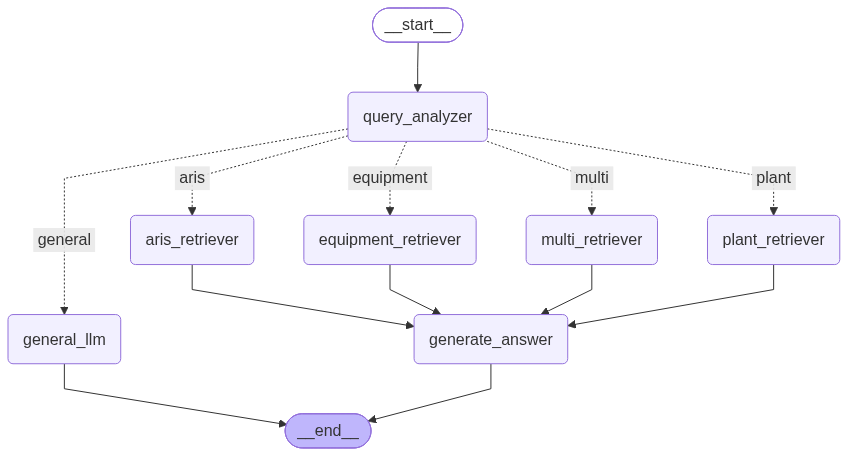

In [92]:
# Visualize graph
try:
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(e)

In [119]:
result = app.invoke({
    "query": "Explain the AGEYE ARIS workflow"
})

print(result["answer"])


c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the AGEYE knowledge base, the **ARIS workflow** consists of multiple stages that transform raw agricultural data into structured analysis results. \n\nTo support intelligent analysis and automation, the process utilizes the following core capabilities and components:\n* **Data Gathering & Sensing:** Image acquisition and sensor-data processing\n* **Computer Vision & Detection:** Plant detection, leaf detection, and image segmentation\n* **Analysis:** Feature extraction and plant analysis\n* **Operations & Validation:** Machine monitoring and data validation\n* **Output:** Result generation and reporting', 'extras': {'signature': 'EsMUCsAUARFNMg/OcL6hHvEbYoh/3v2NqV+DD3EUECt5/3hIBGq7XxKQwc+mgVUfxLUNnrpDJWEEUKvNqgi68FP1ZDvjMClUHI1CKXrZWRD/3LZZ09//+9aejgroKKvQn+vTg41EZZlLpNVnqvOsuaDsLrdxR4C+Gi7I3yGcLI9EMR+rq2q3YSmlmFbHQUkJX8AMPuo++OQgstEQuJIIvroGhn/rUaUyWZq7lS+uBqANMXTfb79MJ47X9M7ssIELsXCOquVJhP3NarBonW/1Gyo4xVS0R+QJFCXj69C3zJIgTMNtxtgfb578UtEt9QOwgV8xTu

In [ ]:
print(result)

{'query': 'Explain the AGEYE ARIS workflow', 'keywords': ['aris', 'aris'], 'documents': ['AGEYE ARIS – WORKFLOW\n\nSystem: ARIS\nDomain: AGEYE\nCategory: Intelligent Agricultural Workflow\n\nWorkflow Overview\n\nThe ARIS workflow consists of multiple stages that transform raw agricultural data into structured analysis results.', 'AGEYE ARIS – SYSTEM OVERVIEW\n\nSystem Name: ARIS\nDomain: AGEYE\nCategory: Agricultural Robotics and Intelligent Systems\nPurpose: Intelligent analysis and automation\n\nOverview\n\nARIS is an intelligent system designed to support agricultural operations through automation, sensing, computer vision, data processing, and intelligent decision support.', 'AGEYE ARIS – FEATURES AND COMPONENTS\n\nSystem: ARIS\nDomain: AGEYE\n\nCore Features\n\nARIS can contain the following functional capabilities:\n\nImage acquisition\nPlant detection\nLeaf detection\nImage segmentation\nFeature extraction\nPlant analysis\nMachine monitoring\nSensor-data processing\nData validat

In [128]:
result['query']

'Explain the AGEYE ARIS workflow'

In [129]:
result['keywords']

['aris', 'aris']

In [130]:
result['documents']

['AGEYE ARIS – WORKFLOW\n\nSystem: ARIS\nDomain: AGEYE\nCategory: Intelligent Agricultural Workflow\n\nWorkflow Overview\n\nThe ARIS workflow consists of multiple stages that transform raw agricultural data into structured analysis results.',
 'AGEYE ARIS – SYSTEM OVERVIEW\n\nSystem Name: ARIS\nDomain: AGEYE\nCategory: Agricultural Robotics and Intelligent Systems\nPurpose: Intelligent analysis and automation\n\nOverview\n\nARIS is an intelligent system designed to support agricultural operations through automation, sensing, computer vision, data processing, and intelligent decision support.',
 'AGEYE ARIS – FEATURES AND COMPONENTS\n\nSystem: ARIS\nDomain: AGEYE\n\nCore Features\n\nARIS can contain the following functional capabilities:\n\nImage acquisition\nPlant detection\nLeaf detection\nImage segmentation\nFeature extraction\nPlant analysis\nMachine monitoring\nSensor-data processing\nData validation\nResult generation\nReporting']

In [132]:
result['context']

'AGEYE ARIS – WORKFLOW\n\nSystem: ARIS\nDomain: AGEYE\nCategory: Intelligent Agricultural Workflow\n\nWorkflow Overview\n\nThe ARIS workflow consists of multiple stages that transform raw agricultural data into structured analysis results.\n\nAGEYE ARIS – SYSTEM OVERVIEW\n\nSystem Name: ARIS\nDomain: AGEYE\nCategory: Agricultural Robotics and Intelligent Systems\nPurpose: Intelligent analysis and automation\n\nOverview\n\nARIS is an intelligent system designed to support agricultural operations through automation, sensing, computer vision, data processing, and intelligent decision support.\n\nAGEYE ARIS – FEATURES AND COMPONENTS\n\nSystem: ARIS\nDomain: AGEYE\n\nCore Features\n\nARIS can contain the following functional capabilities:\n\nImage acquisition\nPlant detection\nLeaf detection\nImage segmentation\nFeature extraction\nPlant analysis\nMachine monitoring\nSensor-data processing\nData validation\nResult generation\nReporting'

In [133]:
result['answer']

[{'type': 'text',
  'text': 'Based on the AGEYE knowledge base, the **ARIS workflow** consists of multiple stages that transform raw agricultural data into structured analysis results. \n\nTo support intelligent analysis and automation, the process utilizes the following core capabilities and components:\n* **Data Gathering & Sensing:** Image acquisition and sensor-data processing\n* **Computer Vision & Detection:** Plant detection, leaf detection, and image segmentation\n* **Analysis:** Feature extraction and plant analysis\n* **Operations & Validation:** Machine monitoring and data validation\n* **Output:** Result generation and reporting',
  'extras': {'signature': 'EsMUCsAUARFNMg/OcL6hHvEbYoh/3v2NqV+DD3EUECt5/3hIBGq7XxKQwc+mgVUfxLUNnrpDJWEEUKvNqgi68FP1ZDvjMClUHI1CKXrZWRD/3LZZ09//+9aejgroKKvQn+vTg41EZZlLpNVnqvOsuaDsLrdxR4C+Gi7I3yGcLI9EMR+rq2q3YSmlmFbHQUkJX8AMPuo++OQgstEQuJIIvroGhn/rUaUyWZq7lS+uBqANMXTfb79MJ47X9M7ssIELsXCOquVJhP3NarBonW/1Gyo4xVS0R+QJFCXj69C3zJIgTMNtxtgfb578UtEt9QOwgV

In [ ]:
for output in app.stream({
    "query": "Explain the AGEYE ARIS workflow"
}):

    for node_name, node_output in output.items():

        print("\n" + "=" * 60)
        print("NODE:", node_name)
        print("=" * 60)

        print(node_output)

```
TXT FILES
   ↓
TextLoader
   ↓
Metadata
   ↓
Chunking
   ↓
Gemini Embedding
   ↓
FAISS
   ↓
┌─────────────────────────────┐
│ equipment_vectorstore       │
│ plant_vectorstore           │
│ aris_vectorstore            │
│ general_vectorstore         │
└─────────────────────────────┘
   ↓
LangGraph Router
   ↓
Correct Retriever
   ↓
RAG
   ↓
Gemini
   ↓
Answer

```

```                    
                    
                    START
                      │
                      ▼
              Query Analyzer
                      │
                      ▼
              keywords=["aris"]
                      │
                      ▼
                 Router
                      │
                 "aris"
                      │
                      ▼
              ARIS Retriever
                      │
                      ▼
              Retrieved Context
                      │
                      ▼
             Generate Answer
                      │
                      ▼
                     END
                    
                    
 ```

| User query                           | Expected route | Main knowledge            |
| ------------------------------------ | -------------- | ------------------------- |
| `How is basil analyzed?`             | `plant`        | `basil.txt`               |
| `What is tip-burn analysis?`         | `plant`        | `deficiency_analysis.txt` |
| `How is lettuce analyzed?`           | `plant`        | `lettuce.txt`             |
| `How is hemp segmented?`             | `plant`        | `hemp.txt`                |
| `What is ARIS?`                      | `aris`         | `aris_overview.txt`       |
| `Explain the ARIS workflow`          | `aris`         | `aris_workflow.txt`       |
| `What are ARIS features?`            | `aris`         | `aris_features.txt`       |
| `What is AGEYE?`                     | `general`      | `ageye_overview.txt`      |
| `What are the major areas of AGEYE?` | `general`      | `ageye_overview.txt`      |


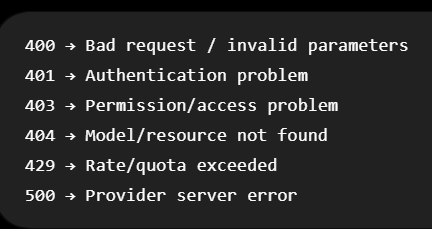